# **Data Pipline**

#### clean metadata, extract audio features with librosa, produce the master parquet

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import librosa
import numpy as np
import faiss

# Paths
# Paths
raw_dir = Path("D:/music_data/raw")
metadata_dir = raw_dir / "fma_metadata"
processed_dir = Path("D:/music_data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
# Load our cleaned track list
df = pd.read_parquet(processed_dir / "tracks_clean.parquet")
print(f"Tracks to process: {len(df)}")

Tracks to process: 106574


In [2]:
# Paths
audio_dir = Path("D:/music_data/raw/fma_large")
features_dir = Path("D:/music_data/essentia_features")
processed_dir = Path("D:/music_data/processed")
features_dir.mkdir(parents=True, exist_ok=True)

# Load track list
df = pd.read_parquet(processed_dir / "tracks_clean.parquet")
print(f"Tracks to process: {len(df)}")

Tracks to process: 106574


In [3]:
#extracts tempo, spectral features, and chroma
def extract_features(audio_path):
    try:
        y, sr = librosa.load(audio_path, duration=30)

        #BPM (_ throwaway veriable)
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        tempo = float(np.asarray(tempo).flatten()[0])

        #energy
        energy = float(np.mean(librosa.feature.rms(y=y)))

        #key
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
        key = int(np.argmax(chroma.mean(axis=1)))

        return {"bpm" : tempo, "energy": energy, "key": key, "status": "ok"}

    except Exception  as e:
        return {"status": "error", "error": str(e)}


# run on all tracks
errors = []
skipped = 0

for _,row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    track_id = row['track_id']
    out_path = features_dir / f"{str(track_id).zfill(6)}.json"

    # Skip if already done
    if out_path.exists():
        skipped += 1
        continue

    folder = str(track_id).zfill(6)[:3]
    audio_path = audio_dir/ folder / f"{str(track_id).zfill(6)}.mp3"

    if not audio_path.exists():
        errors.append(track_id)
        continue

    features = extract_features(audio_path)

    with open(out_path, 'w') as f:
        json.dump(features, f)

print(f"\nDone")
print(f"Skipped (already done): {skipped}")
print(f"Error:  {len(errors)}")

    

Extracting features:   0%|          | 0/106574 [00:00<?, ?it/s]


Done
Skipped (already done): 106574
Error:  0


## **merge metadata + features into master Parquet**

In [7]:
print(f"df length: {len(df)}")
print(f"Sample track_id: {df['track_id'].iloc[0]}")

# Check a json file exists
test_id = df['track_id'].iloc[1]
test_path = features_dir / f"{str(test_id).zfill(6)}.json"
print(f"Test path: {test_path}")
print(f"Exists: {test_path.exists()}")

# Try loading it
with open(test_path) as f:
    test_features = json.load(f)
print(f"Features: {test_features}")

df length: 106574
Sample track_id: 2
Test path: D:\music_data\essentia_features\000003.json
Exists: True
Features: {'bpm': 86.1328125, 'energy': 0.11790983378887177, 'key': 7, 'status': 'ok'}


In [5]:
#merge feautures with meta data
df = pd.read_parquet(processed_dir / "tracks_clean.parquet")

records = []

# _ throw away variable
for _, row in tqdm(df.iterrows(), total=len(df), desc="Merging feautures"):
    track_id =  row['track_id']
    json_path = features_dir / f"{str(track_id).zfill(6)}.json"

    if not json_path.exists():
        continue

    with open(json_path) as f:
        features = json.load(f)

    if features.get('status') != 'ok':
        continue

    records.append({
        'track_id': track_id,
        'title': row['title'],
        'artist': row['artist'],
        'genre':    row['genre'],
        'duration': row['duration'],
        'subset':   row['subset'],
        'bpm':      features['bpm'],
        'energy':   features['energy'],
        'key':      features['key']
    })

merged = pd.DataFrame(records)
print(f"Merged tracks; {len(merged)}")
print(merged.head())

        

Merging feautures:   0%|          | 0/106574 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Save merged dataset
out_path = processed_dir / "ab_fma_v3.parquet"
merged.to_parquet(out_path, index=False)
print(f"Saved {len(merged)} tracks to {out_path}")

# Phase 3: Generate Embedding

#### replace VGGish 128-dim with CLAP 512 dim for richer sonic similarity
#### CLAP(contrastive language-Audio Pretraining) capture timbral texture, mood, and stylistic nuance a much finer resolution
##### generates 512 dimentional vectors for each track

In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [9]:
# pipeline to generate embedding
embeddings_dir = Path("D:/music_data/embeddings")
embeddings_dir.mkdir(parents=True, exist_ok=True)

model.eval()

errors = []
skipped = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc="Generating embeddings"):
    track_id = row['track_id']
    out_path = embeddings_dir / f"{str(track_id).zfill(6)}.npy"

    # Skip if already done
    if out_path.exists():
        skipped += 1
        continue

    folder = str(track_id).zfill(6)[:3]
    audio_path = audio_dir / folder / f"{str(track_id).zfill(6)}.mp3"

    if not audio_path.exists():
        errors.append(track_id)
        continue

    try:
        y, sr = librosa.load(audio_path, sr=48000, duration=30, mono=True)
        inputs = processor(audio=y, sampling_rate=48000, return_tensors="pt")
        inputs = {k: v.to("cuda") if hasattr(v, 'to') else v for k, v in inputs.items()}

        with torch.no_grad():
            output = model.get_audio_features(**inputs)

        embedding = output.pooler_output.cpu().numpy().flatten()
        np.save(out_path, embedding)

    except Exception as e:
        errors.append(track_id)

print(f"\nDone")
print(f"Skipped: {skipped}")
print(f"Errors: {len(errors)}")

Generating embeddings:   0%|          | 0/106574 [00:00<?, ?it/s]

C:\Users\nakay\AppData\Local\Temp\ipykernel_37088\1246134042.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=48000, duration=30, mono=True)
C:\Users\nakay\Documents\seniorProjectDocker\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
C:\Users\nakay\AppData\Local\Temp\ipykernel_37088\1246134042.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=48000, duration=30, mono=True)
C:\Users\nakay\Documents\seniorProjectDocker\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Done
Skipped: 106412
Errors:  162


In [ ]:
#check how much data we retained
npy_files = list(embeddings_dir.glob("*.npy"))
print(f"Total embeddings: {len(npy_files)}")
print(f"Bad tracks skipped: {len(errors)}")
print(f"Coverage: {len(npy_files)/106574*100:.2f}%")

# Phase 4
### Build FAISS Index
#### switch from HNSW flat to IVF+PQ to handle 25K - 100k 512-dim vectors

In [10]:
#Build IVF+PQ Index

index_dir = Path("D:/music_data/index")
index_dir.mkdir(parents=True, exist_ok=True)

# load all embeddings into a matrix
npy_files = sorted(embeddings_dir.glob("*.npy"))
track_ids = []
vectors = []

for f in tqdm(npy_files, desc="Loading embeddings"):
    track_id = int(f.stem)
    vec = np.load(f)
    track_ids.append(track_id)
    vectors.append(vec)

vectors = np.stack(vectors).astype(np.float32)
print(f"Matrix shape: {vectors.shape}")
      


Loading embeddings:   0%|          | 0/106412 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# FAISS index

# Normalize vectors for cosine similiarity
faiss.normalize_L2(vectors)

#build IVF-PQ index
n_vectors = len(vectors)
dimension = 512
nlist = 256 # number of clusters
m = 32 # number of sub-vectors for PQ

quantizer = faiss.IndexFlatL2(dimension)
index = faiss.IndexIVFPQ(quantizer, dimension, nlist, m, 8)

#Traain the index
print("Training index...")
index.train(vectors)
print("Training done!")

print("Adding vectors...")
index.add(vectors)
print(f"Total vectors in index: {index.ntotal}")

#save index
index_path = index_dir / "faiss_ivfpqV3.index"
faiss.write_index(index, str(index_path))
print(f"index saved to {index_path}")

#save track ID map
id_map_path = index_dir /"track_id_map_V3.json"
with open(id_map_path, 'w') as f:
          json.dump(track_ids, f)
print(f"Track ID map saved to {id_map_path}")


In [ ]:
#sanity check
# Test the index - find 5 similar tracks to track 2
index.nprobe = 64  # search 64 clusters for better recall

query_id  = track_ids.index(2)  # find position of track 2 in our list
query_vec = vectors[query_id].reshape(1, -1)

distances, indices = index.search(query_vec, 6)  # 6 because first result is the song itself

print(f"Query track: {df[df['track_id']==2][['title','artist','genre']].values[0]}")
print(f"\nTop 5 similar tracks:")
for i, idx in enumerate(indices[0][1:]):
    tid = track_ids[idx]
    row = df[df['track_id'] == tid][['title', 'artist', 'genre']].values
    if len(row) > 0:
        print(f"  {i+1}. {row[0]} (distance: {distances[0][i+1]:.4f})")

# Phase 5 Load data into MySQL

In [ ]:
import pandas as pd
df = pd.read_parquet(r"D:\music_data\processed\ab_fma_v3.parquet")
print(df.columns.tolist())
print(df.shape)
print(df.head(2))

# metrics

In [ ]:
import faiss, json, numpy as np
from pathlib import Path

index = faiss.read_index(r"D:\music_data\index\faiss_ivfpqV3.index")
index.nprobe = 64
with open(r"D:\music_data\index\track_id_map_V3.json") as f:
    track_ids = json.load(f)
print(f"Index: {index.ntotal} | track_ids: {len(track_ids)}")

In [5]:
emb_dir = Path(r"D:\music_data\embeddings")
npy_files = sorted(emb_dir.glob("*.npy"), key=lambda p: int(p.stem))
vectors = np.stack([np.load(f) for f in npy_files]).astype(np.float32)
faiss.normalize_L2(vectors)
print(f"Vectors: {vectors.shape}")

Vectors: (106412, 512)


In [6]:
import pandas as pd
df = pd.read_parquet(r"D:\music_data\processed\ab_fma_v3.parquet")
print(df.columns.tolist())

['track_id', 'title', 'artist', 'genre', 'duration', 'subset', 'bpm', 'energy', 'key']


In [9]:
import time, json
import numpy as np

QUERY_IDS = [2, 3, 5, 134, 1000]
FAISS_K = 50
FINAL_K = 10

def get_parquet_features(fma_id):
    row = df[df['track_id'] == fma_id]
    if row.empty:
        return None
    r = row.iloc[0]
    return {
        'bpm':float(r.get('bpm',    0) or 0),
        'energy': float(r.get('energy', 0) or 0),
        'key':float(r.get('key',    0) or 0),
    }

def librosa_score(q, c):
    if not q or not c:
        return 0.0
    bpm_sim = 1 - min(abs(q['bpm']    - c['bpm'])    / 200, 1)
    energy_sim = 1 - min(abs(q['energy'] - c['energy']) / 1,   1)
    key_sim = 1.0 if q['key'] == c['key'] else 0.5
    return round(bpm_sim * 0.4 + energy_sim * 0.4 + key_sim * 0.2, 4)

results = []

for fma_id in QUERY_IDS:
    if fma_id not in track_ids:
        print(f"skipping {fma_id} — not in index")
        continue

    pos = track_ids.index(fma_id)
    query_vec = vectors[pos].reshape(1, -1)
    q_feats = get_parquet_features(fma_id)
    q_label = df[df['track_id'] == fma_id]['title'].values
    q_label = str(q_label[0]) if len(q_label) else str(fma_id)

    t0 = time.perf_counter()
    distances, indices_out = index.search(query_vec, FAISS_K + 1)
    t1 = time.perf_counter()

    faiss_pairs = [
        (track_ids[idx], float(dist))
        for idx, dist in zip(indices_out[0], distances[0])
        if track_ids[idx] != fma_id
    ][:FAISS_K]

    scored = [
        (tid, fscore, librosa_score(q_feats, get_parquet_features(tid)))
        for tid, fscore in faiss_pairs
    ]
    scored.sort(key=lambda x: x[2], reverse=True)
    t2 = time.perf_counter()

    candidates = []
    for rank_l, (tid, fscore, lscore) in enumerate(scored[:FINAL_K]):
        rank_f = next(i for i, (t, s) in enumerate(faiss_pairs) if t == tid)
        candidates.append({
            "track_id": tid,
            "rank_faiss": rank_f + 1,
            "rank_librosa": rank_l + 1,
            "faiss_score": round(fscore, 4),
            "librosa_score": lscore,
        })

    results.append({
        "query_track_id": fma_id,
        "query_label": q_label,
        "total_latency_ms": round((t2 - t0) * 1000, 1),
        "faiss_latency_ms": round((t1 - t0) * 1000, 1),
        "rerank_latency_ms": round((t2 - t1) * 1000, 1),
        "candidates": candidates,
    })

    print(f"✓ {q_label:30s}  FAISS: {round((t1-t0)*1000,1):6.1f}ms  "
          f"rerank: {round((t2-t1)*1000,1):6.1f}ms  "
          f"total: {round((t2-t0)*1000,1):6.1f}ms")

with open(r"D:\music_data\figure3_data.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\nSaved → D:\\music_data\\figure3_data.json")

✓ Food                            FAISS:    1.9ms  rerank:   31.5ms  total:   33.5ms
✓ Electric Ave                    FAISS:    0.8ms  rerank:   26.4ms  total:   27.1ms
✓ This World                      FAISS:    0.7ms  rerank:   28.0ms  total:   28.7ms
✓ Street Music                    FAISS:    0.7ms  rerank:   26.8ms  total:   27.5ms
✓ Bless You                       FAISS:    0.6ms  rerank:   26.3ms  total:   27.0ms

Saved → D:\music_data\figure3_data.json


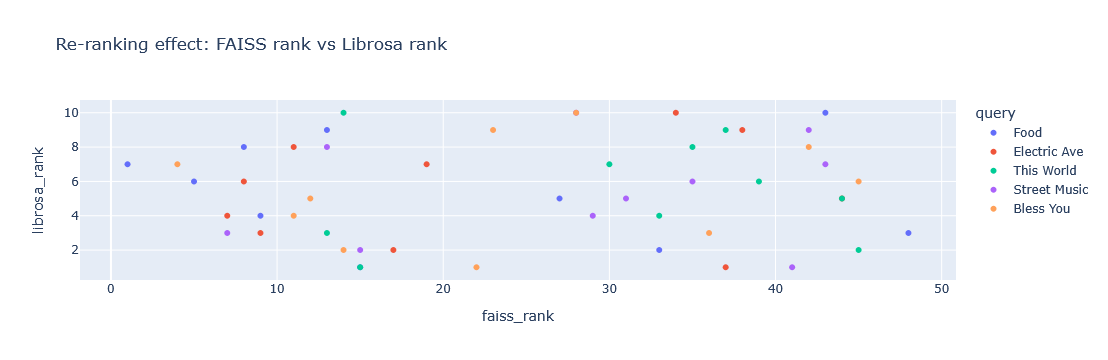

In [5]:
import subprocess
subprocess.run(["pip", "install", "plotly"], check=True)
import plotly.express as px
import pandas as pd, json

with open(r"D:\music_data\figure3_data.json") as f:
    data = json.load(f)

rows = []
for q in data:
    for c in q['candidates']:
        rows.append({
            'query': q['query_label'],
            'faiss_rank': c['rank_faiss'],
            'librosa_rank': c['rank_librosa'],
            'faiss_score': c['faiss_score'],
            'librosa_score': c['librosa_score'],
        })

df_plot = pd.DataFrame(rows)
fig = px.scatter(df_plot, x='faiss_rank', y='librosa_rank',
                 color='query', size_max=10,df = pd.read_parquet(r"D:\music_data\processed\ab_fma_v3.parquet")
print(df.columns.tolist())
                 title='Re-ranking effect: FAISS rank vs Librosa rank')
fig.show()

In [7]:
df = pd.read_parquet(r"D:\music_data\processed\ab_fma_v3.parquet")
print(df.columns.tolist())

['track_id', 'title', 'artist', 'genre', 'duration', 'subset', 'bpm', 'energy', 'key']


In [8]:
import json, numpy as np

with open(r"D:\music_data\figure3_data.json") as f:
    data = json.load(f)

rows = []
for q in data:
    q_row = df[df['track_id'] == q['query_track_id']].iloc[0]
    query_genre = q_row['genre']
    query_bpm   = float(q_row['bpm'] or 0)

    faiss_top10   = sorted(q['candidates'], key=lambda x: x['rank_faiss'])[:10]
    librosa_top10 = sorted(q['candidates'], key=lambda x: x['rank_librosa'])[:10]

    for stage, candidates in [('FAISS', faiss_top10), ('Librosa', librosa_top10)]:
        genre_matches, bpm_diffs, lscores = [], [], []
        for c in candidates:
            c_row = df[df['track_id'] == c['track_id']]
            if c_row.empty:
                continue
            c_row = c_row.iloc[0]
            genre_matches.append(int(c_row['genre'] == query_genre))
            bpm_diffs.append(abs(float(c_row['bpm'] or 0) - query_bpm))
            lscores.append(c['librosa_score'])

        rows.append({
            'query': q['query_label'],
            'query_genre': query_genre,
            'stage': stage,
            'genre_precision': round(np.mean(genre_matches) * 100, 1),
            'avg_bpm_diff': round(np.mean(bpm_diffs), 1),
            'avg_librosa_score': round(np.mean(lscores), 4),
        })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))

print("\n── Overall ──────────────────────────────────────")
for stage in ['FAISS', 'Librosa']:
    s = df_metrics[df_metrics['stage'] == stage]
    print(f"{stage:8s}  genre precision: {s['genre_precision'].mean():.1f}%  "
          f"avg BPM diff: {s['avg_bpm_diff'].mean():.1f}  "
          f"avg librosa score: {s['avg_librosa_score'].mean():.4f}")

       query  query_genre   stage  genre_precision  avg_bpm_diff  avg_librosa_score
        Food      Hip-Hop   FAISS             70.0          14.7             0.8610
        Food      Hip-Hop Librosa             70.0          14.7             0.8610
Electric Ave      Hip-Hop   FAISS             80.0           5.7             0.9205
Electric Ave      Hip-Hop Librosa             80.0           5.7             0.9205
  This World      Hip-Hop   FAISS             80.0           7.7             0.9516
  This World      Hip-Hop Librosa             80.0           7.7             0.9516
Street Music      Hip-Hop   FAISS             90.0          23.4             0.8387
Street Music      Hip-Hop Librosa             90.0          23.4             0.8387
   Bless You Experimental   FAISS             50.0           7.7             0.9001
   Bless You Experimental Librosa             50.0           7.7             0.9001

── Overall ──────────────────────────────────────
FAISS     genre precision